In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from tqdm.notebook import tqdm

In [2]:
def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(0, x)

def drelu(act: np.ndarray, grad: np.ndarray) -> np.ndarray:
    return grad * np.where(act > 0, 1, 0)

In [3]:
def generate_images_with_squares(
        num_images: int = 100000,
        contrast: int = 50,
        seed: int = 42
) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    if contrast < 0 or contrast > 100:
        raise ValueError("0 <= Contrast <= 100")

    c = int(199 * contrast/100)
    img = rng.integers(0, 200 - c, [num_images, 64, 64], dtype=np.uint8 )
    square = rng.integers(c, 200, [num_images, 15, 15], dtype=np.uint8)
    real_coords = rng.integers(20, 44, size=(num_images, 2))

    for i in range(num_images):
        x, y = real_coords[i]

        img[i, (y-7):(y+8), (x-7):(x+8)] = square[i]

    return img, real_coords

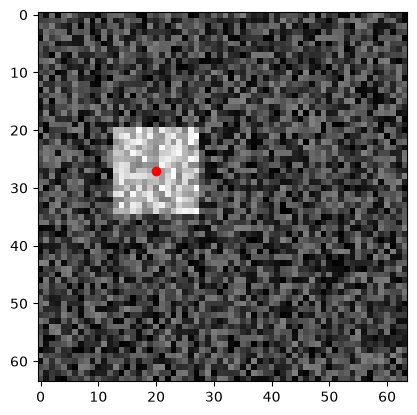

In [4]:
imgs, real_coords = generate_images_with_squares(num_images=1, contrast=50)
plt.imshow(imgs[0], cmap="grey")
plt.plot(real_coords[0][0], real_coords[0][1], marker='o', color="red")

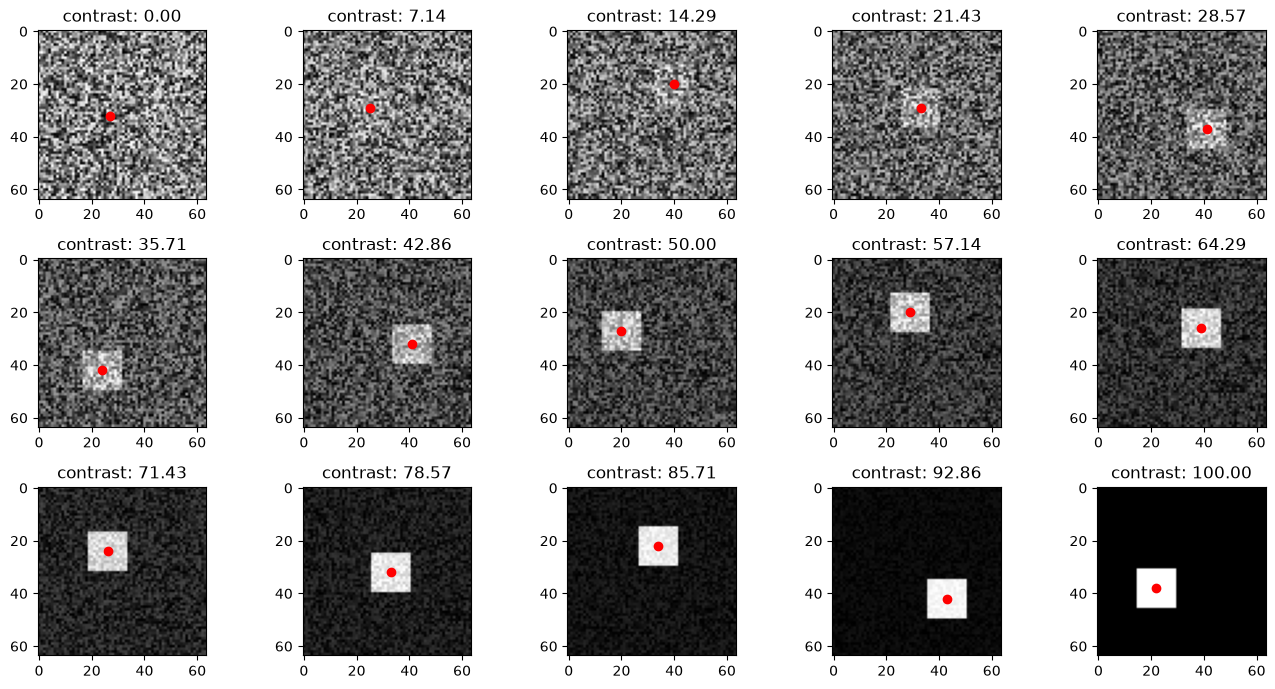

In [5]:
fig, ax = plt.subplots(3, 5, figsize=(14, 7))
ax_copy = ax.flatten()
for i, contrast in enumerate(np.linspace(0, 100, 15)):
    imgs, real_coords = generate_images_with_squares(1, contrast=contrast)
    ax_copy[i].imshow(imgs[0], cmap="grey")
    ax_copy[i].plot(real_coords[0][0], real_coords[0][1], marker='o', color="red")
    ax_copy[i].set_title(f"contrast: {contrast:.2f}")
    plt.tight_layout()

In [6]:
def normalize(sample: np.ndarray) -> np.ndarray:
    s_min = np.min(sample, axis=-1, keepdims=True)
    s_max = np.max(sample, axis=-1, keepdims=True)
    return (sample - s_min)/(s_max - s_min)* 2 - 1

def initialization_param(size: tuple[int, int], mode: str = "randn", bound: float = None, seed: int = None) -> np.ndarray:
    rng = np.random.default_rng(seed)

    if mode == "randn":
        return rng.standard_normal(size=size)
    elif mode == "uniform":
        return rng.uniform(-bound, bound, size=size)
    else:
        raise ValueError(f"Такого параметра mode пока нет")

def create_layers(in_features: int, out_features: int, mode: str = 'randn', seed: int = None):
    W1 = initialization_param((in_features, 128), mode=mode, bound=np.sqrt(6 / in_features), seed=seed)
    b1 = initialization_param((1, 128), mode=mode, bound=np.sqrt(6 / 128), seed=seed)
    
    W2 = initialization_param((128, out_features), mode=mode, bound=np.sqrt(6 / in_features), seed=seed)
    b2 = initialization_param((1, out_features), mode=mode, bound=np.sqrt(6 / 2), seed=seed)

    return W1, b1, W2, b2

In [10]:
def train(
        data: tuple[np.ndarray, np.ndarray],
        in_features: int, 
        out_features: int, 
        init_mode: str = "randn",
        batch_size: int = 16,
        epochs: int = 1,
        lr: float = 0.001,
        shuffle: bool = False,
        norm = False,
        seed = None,
        ):
    W1, b1, W2, b2 = create_layers(in_features, out_features, mode=init_mode, seed=seed)
    imgs, real_coords = data

    data_size = imgs.shape[0]
    num_batches = data_size//batch_size
    total = num_batches * batch_size

    print(f"Размер батча: {batch_size}")
    print(f"Количество батчей: {num_batches}")

    for epoch in range(epochs):
        if shuffle:
            rng = np.random.default_rng(seed+epoch)
            idx = rng.permutation(data_size)
            imgs = imgs[idx]
            real_coords = real_coords[idx]

        imgs_batches = imgs[:total].reshape(num_batches, batch_size, in_features)
        coords_batches = real_coords[:total].reshape(num_batches, batch_size, out_features)

        if norm:
            imgs_batches = normalize(imgs_batches)

        train_loader = (imgs_batches, coords_batches)
        train_loop = tqdm(zip(*train_loader), leave=False)

        for i, (imgs_batch, coords_batch) in enumerate(train_loop):
            out1 = imgs_batch @ W1 + b1
            act1 = relu(out1)

            pred = act1 @ W2 + b2

            E = coords_batch - pred
            R = E**2
            s = np.sum(R)
            MSE = s/R.size

            dMSE = 1
            ds = dMSE * 1/R.size
            dR = ds * np.ones_like(R)
            dE = dR * 2 * E
            dpred = -dE

            db2 = np.sum(dpred, axis=0, keepdims=True)
            dW2 = act1.T @ dpred

            dact1 = dpred @ W2.T
            dout1 = drelu(act1, dact1)

            db1 = np.sum(dout1, axis=0, keepdims=True)
            dW1 = imgs_batch.T @ dout1

            if i % 100 == 0:
                print(f"Epoch [{epoch+1}/{epochs}], MSE = {MSE:.4f}")
                print()

            if i % 100 == 0:
                img, r_coord = imgs[i], real_coords[i]
                img = img.reshape(1, -1)
                if norm:
                    img = normalize(img)

                out1 = img@ W1 + b1
                act1 = relu(out1)
                pred = act1@ W2 + b2
                print(f"real_coord= {r_coord}")
                print(f"pred= {pred[0].round(3)}")

            W1 -= lr * dW1
            b1 -= lr * db1
            W2 -= lr*dW2
            b2 -=lr*db2

    return W1, b1, W2, b2         

In [8]:
data_size = 10000
contrast = 30
seed = 1961

data = generate_images_with_squares(
    num_images=data_size,
    contrast=contrast,
    seed=seed
)

In [11]:
W1, b1, W2, b2 = train(data, in_features=64*64, out_features=2, init_mode="uniform", batch_size=16, epochs=2, lr=0.001, shuffle=True, norm=True, seed=seed)

Размер батча: 16
Количество батчей: 625


0it [00:00, ?it/s]

Epoch [1/2], MSE = 1164.8059

real_coord= [26 20]
pred= [ 0.228 -1.486]
Epoch [1/2], MSE = 13.5833

real_coord= [27 28]
pred= [25.148 25.282]
Epoch [1/2], MSE = 4.4405

real_coord= [27 37]
pred= [23.287 36.946]
Epoch [1/2], MSE = 2.6838

real_coord= [34 32]
pred= [34.619 31.39 ]
Epoch [1/2], MSE = 2.9139

real_coord= [29 43]
pred= [31.109 42.404]
Epoch [1/2], MSE = 4.2632

real_coord= [30 20]
pred= [27.12  20.992]
Epoch [1/2], MSE = 1.6737

real_coord= [39 33]
pred= [36.715 30.233]


0it [00:00, ?it/s]

Epoch [2/2], MSE = 3.7373

real_coord= [24 40]
pred= [26.756 42.358]
Epoch [2/2], MSE = 2.6389

real_coord= [24 29]
pred= [23.297 29.207]
Epoch [2/2], MSE = 2.4595

real_coord= [26 42]
pred= [28.622 40.353]
Epoch [2/2], MSE = 2.2626

real_coord= [30 30]
pred= [31.042 29.406]
Epoch [2/2], MSE = 2.8922

real_coord= [32 31]
pred= [33.692 30.301]
Epoch [2/2], MSE = 2.5472

real_coord= [24 22]
pred= [24.98  22.085]
Epoch [2/2], MSE = 4.4646

real_coord= [36 29]
pred= [36.598 29.454]


In [36]:
test_data, test_target = generate_images_with_squares(6, contrast=32, seed=43)
test_data_ = test_data.reshape(6, -1)

test_data_ = normalize(test_data_)
pred = relu(test_data_ @ W1 + b1) @ W2 + b2

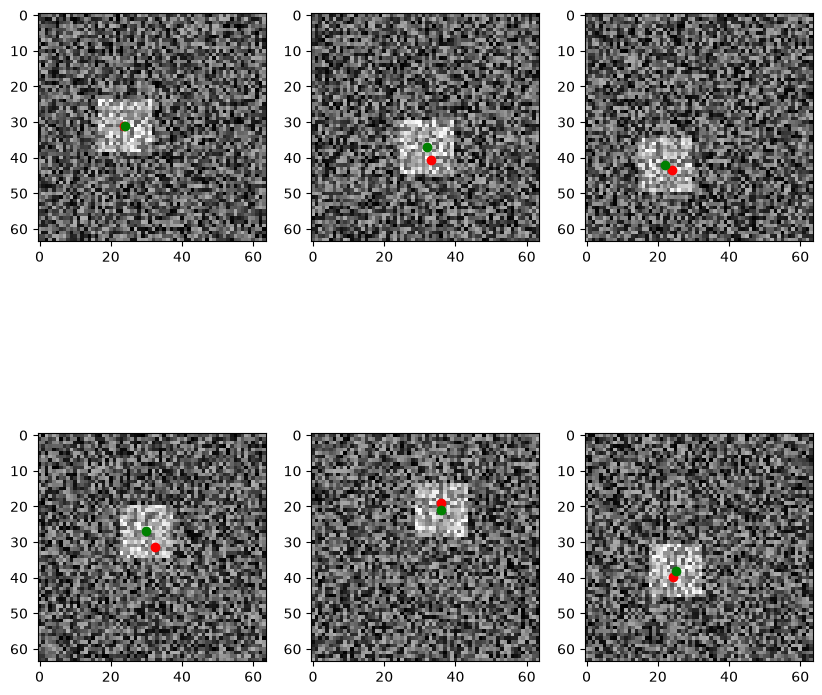

In [37]:
fig, ax = plt.subplots(2, 3, figsize=(10, 10))
ax = ax.flatten()

for i in range(len(ax)):
    ax[i].imshow(test_data[i], cmap="grey")
    ax[i].plot(pred[i][0], pred[i][1], color="red", marker='o')
    ax[i].plot(test_target[i][0], test_target[i][1], color="green", marker='o')